# Import libraries & Load Data

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")

df = pd.read_csv("titanic.csv")

df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


# EDA & Data Cleaning

In [27]:
print("DATA INFORMATION")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# Data Cleaning

df["Age"].fillna(df["Age"].median(), inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

if "Cabin" in df.columns:
    df.drop(columns=["Cabin"], inplace=True)

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None

MISSING VALUES
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          3

C:\Users\RUPAM MAHATO\AppData\Local\Temp\ipykernel_6944\160105437.py:12: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\RUPAM MAHATO\AppData\Local\Temp\ipykernel_6944\160105437.py:14: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

# Basic Visual Report

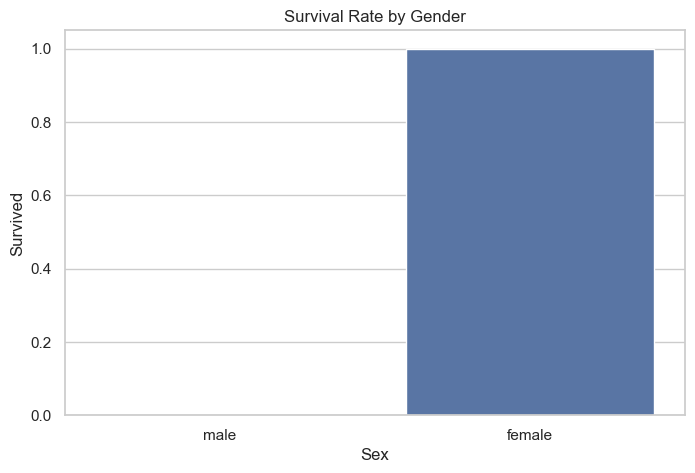

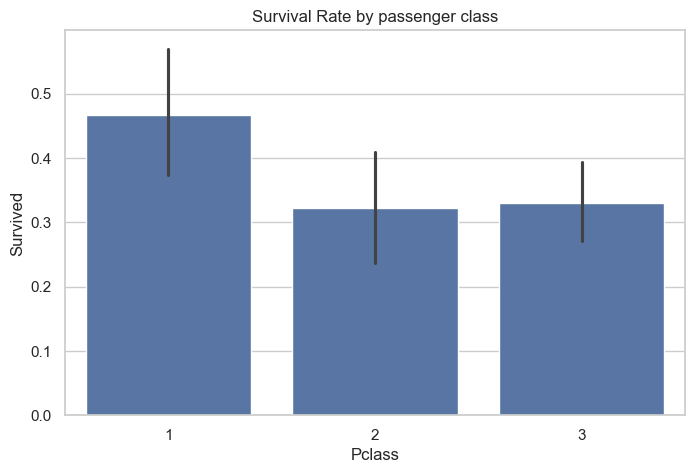

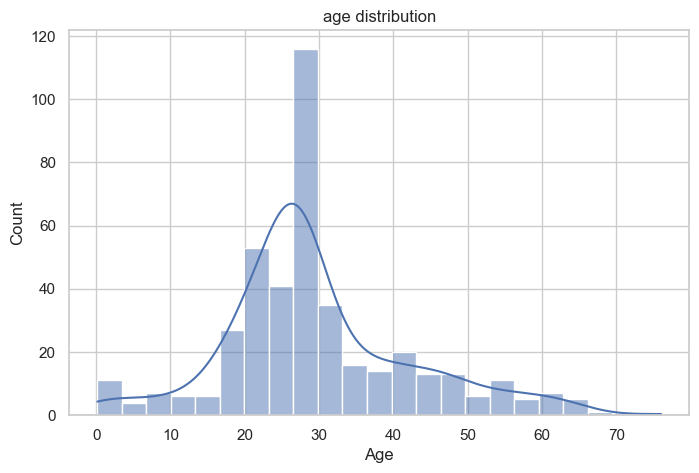

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival Rate by Gender")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Survival Rate by passenger class")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], kde=True)
plt.title("age distribution")
plt.show()

Insight:
# Female passengers had a higher survival rate than male passengers.
# First-class passengers survived more often than lower classes.
# Most passengers were between 20 and 35 years old.    

# Advanced Visualization

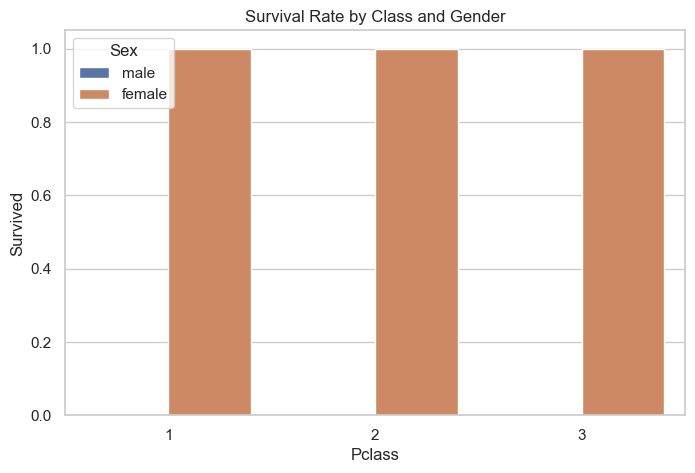

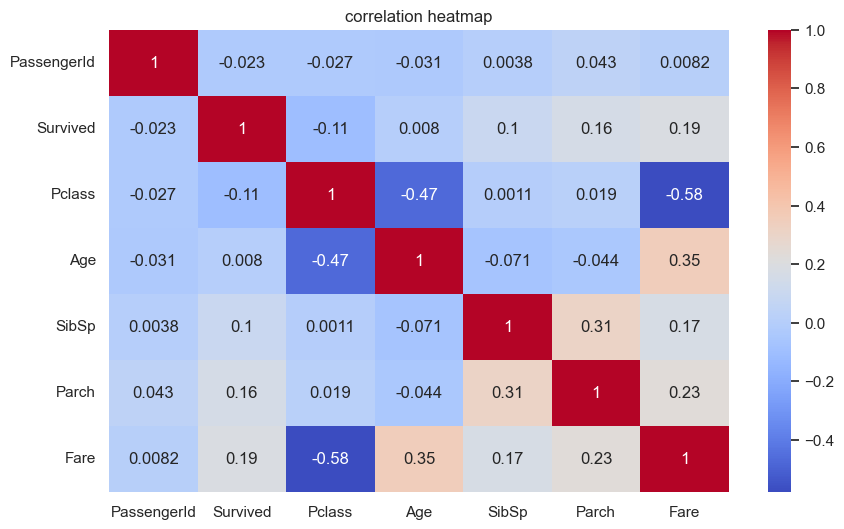

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rate by Class and Gender")
plt.show()

numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("correlation heatmap")
plt.show()

Insight:
# Female passengers in first class had the highest survival rate.
# Passenger class and fare showed relationships with survival.

# Interactive Visualization & Summary

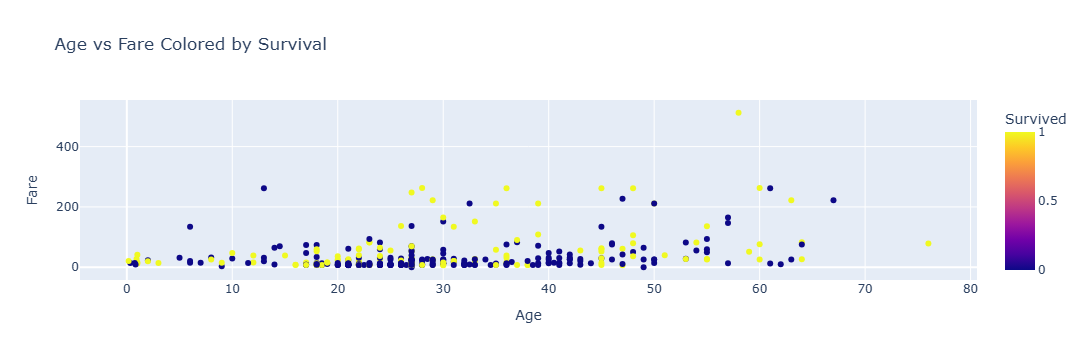

EXECUTIVE SUMMARY
----------------------------------------
Overall Survival Rate: 36.36%
Women survived more than men.
1st Class passengers survived more than 3rd Class passengers.
Gender and Passenger Class are the strongest factors affecting survival.


In [20]:
fig = px.scatter(
    df,
    x="Age",
    y="Fare",
    color="Survived",
    hover_data=["Pclass", "Sex"],
    title="Age vs Fare Colored by Survival"
)

fig.show()

overall_survival = round(df["Survived"].mean()*100,2)

print("EXECUTIVE SUMMARY")
print("-"*40)

print(f"Overall Survival Rate: {overall_survival}%")
print("Women survived more than men.")
print("1st Class passengers survived more than 3rd Class passengers.")
print("Gender and Passenger Class are the strongest factors affecting survival.")

In [ ]:
Insight:
# Passengers paying higher fares generally had better survival chances.

# Save All Titanic Charts as PNG

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1 - Survival Rate by Gender
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival Rate by Gender")
plt.savefig("chart1_gender_survival.png", dpi=300, bbox_inches="tight")
plt.close()

# Chart 2 - Survival Rate by Passenger Class
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.savefig("chart2_class_survival.png", dpi=300, bbox_inches="tight")
plt.close()

# Chart 3 - Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.savefig("chart3_age_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

# Chart 4 - Survival Rate by Class and Gender
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex")
plt.title("Survival Rate by Class and Gender")
plt.savefig("chart4_class_gender_survival.png", dpi=300, bbox_inches="tight")
plt.close()

# Chart 5 - Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("chart5_heatmap.png", dpi=300, bbox_inches="tight")
plt.close()

print("All 5 Titanic charts saved successfully!")

All 5 Titanic charts saved successfully!


# Save Plotly Chart as HTML

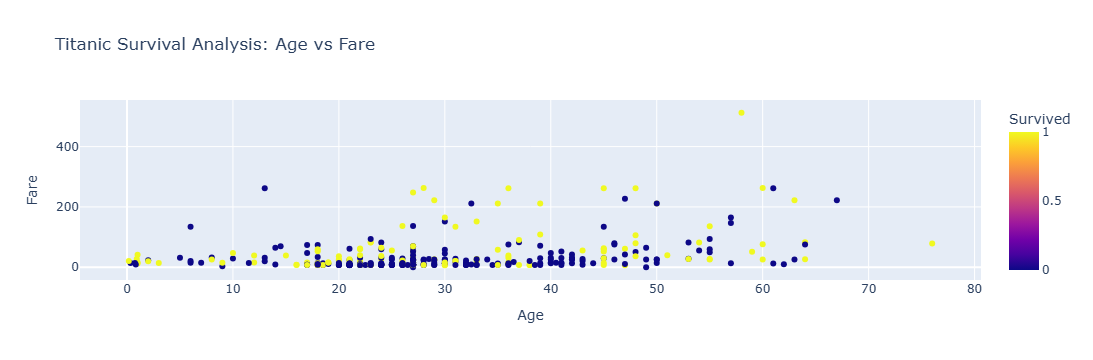

Interactive Scatter Plot saved successfully!


In [30]:
import plotly.express as px

fig = px.scatter(
    df,
    x="Age",
    y="Fare",
    color="Survived",
    hover_data=["Name", "Pclass", "Sex"],
    title="Titanic Survival Analysis: Age vs Fare"
)

fig.show()

# Save as HTML
fig.write_html("Titanic_Interactive_ScatterPlot.html")

print("Interactive Scatter Plot saved successfully!")

# Key Findings
• Female passengers had significantly higher survival rates.

• First-class passengers had better chances of survival.

• Most passengers were between 20–40 years old.

• Fare and passenger class influenced survival outcomes.

• Gender and class were the most important factors affecting survival.